In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.home() / "OCT-RTFL"

RAW = ROOT / "nnUNet_raw" / "Dataset501_DukeNFL"

RUN = (
    ROOT / "nnUNet_results" / "Dataset501_DukeNFL"
    / "nnUNetTrainer_250epochs__nnUNetPlans__2d"
    / "fold_0"
)

VALIDATION = RUN / "validation"
REPORTS = ROOT / "outputs" / "validation_review"
REPORTS.mkdir(parents=True, exist_ok=True)

prediction_files = sorted(VALIDATION.glob("*.png"))

assert len(prediction_files) == 22, (
    f"Expected 22 validation predictions, found {len(prediction_files)}"
)

records = []

for prediction_path in prediction_files:
    case_id = prediction_path.stem

    prediction = np.asarray(Image.open(prediction_path))
    target = np.asarray(Image.open(RAW / "labelsTr" / prediction_path.name))

    assert prediction.shape == target.shape
    assert set(np.unique(prediction)).issubset({0, 1})

    valid = target != 2
    true_nfl = (target == 1) & valid
    predicted_nfl = (prediction == 1) & valid

    tp = np.count_nonzero(true_nfl & predicted_nfl)
    fp = np.count_nonzero(~true_nfl & predicted_nfl)
    fn = np.count_nonzero(true_nfl & ~predicted_nfl)

    denominator = 2 * tp + fp + fn
    dice = 2 * tp / denominator if denominator else np.nan

    records.append({
        "case_id": case_id,
        "subject_id": case_id.split("_b")[0],
        "dice": dice,
        "true_nfl_pixels": int(true_nfl.sum()),
        "predicted_nfl_pixels": int(predicted_nfl.sum()),
        "false_positive_pixels": int(fp),
        "false_negative_pixels": int(fn),
    })

scores = pd.DataFrame(records).sort_values("dice").reset_index(drop=True)

scores.to_csv(REPORTS / "per_scan_metrics.csv", index=False)

print(f"Mean per-scan Dice: {scores['dice'].mean():.4f}")
print(f"Median Dice:       {scores['dice'].median():.4f}")
print(f"Lowest Dice:       {scores['dice'].min():.4f}")
print(f"Highest Dice:      {scores['dice'].max():.4f}")

display(scores.groupby("subject_id")["dice"].agg(["count", "mean", "min", "max"]))
display(scores.head(5))

Mean per-scan Dice: 0.8702
Median Dice:       0.8830
Lowest Dice:       0.7839
Highest Dice:      0.9247


,count,mean,min,max
subject_id,,,,
Subject_05,11,0.858551,0.783931,0.909008
Subject_10,11,0.881907,0.810680,0.924746


,case_id,subject_id,dice,true_nfl_pixels,predicted_nfl_pixels,false_positive_pixels,false_negative_pixels
0,Subject_05_b030,Subject_05,0.783931,4804,4531,872,1145
1,Subject_05_b033,Subject_05,0.792060,4084,5236,1545,393
2,Subject_05_b028,Subject_05,0.794575,4463,4606,1003,860
3,Subject_10_b030,Subject_10,0.810680,3305,3736,882,451
4,Subject_10_b032,Subject_10,0.825578,3414,3764,801,451


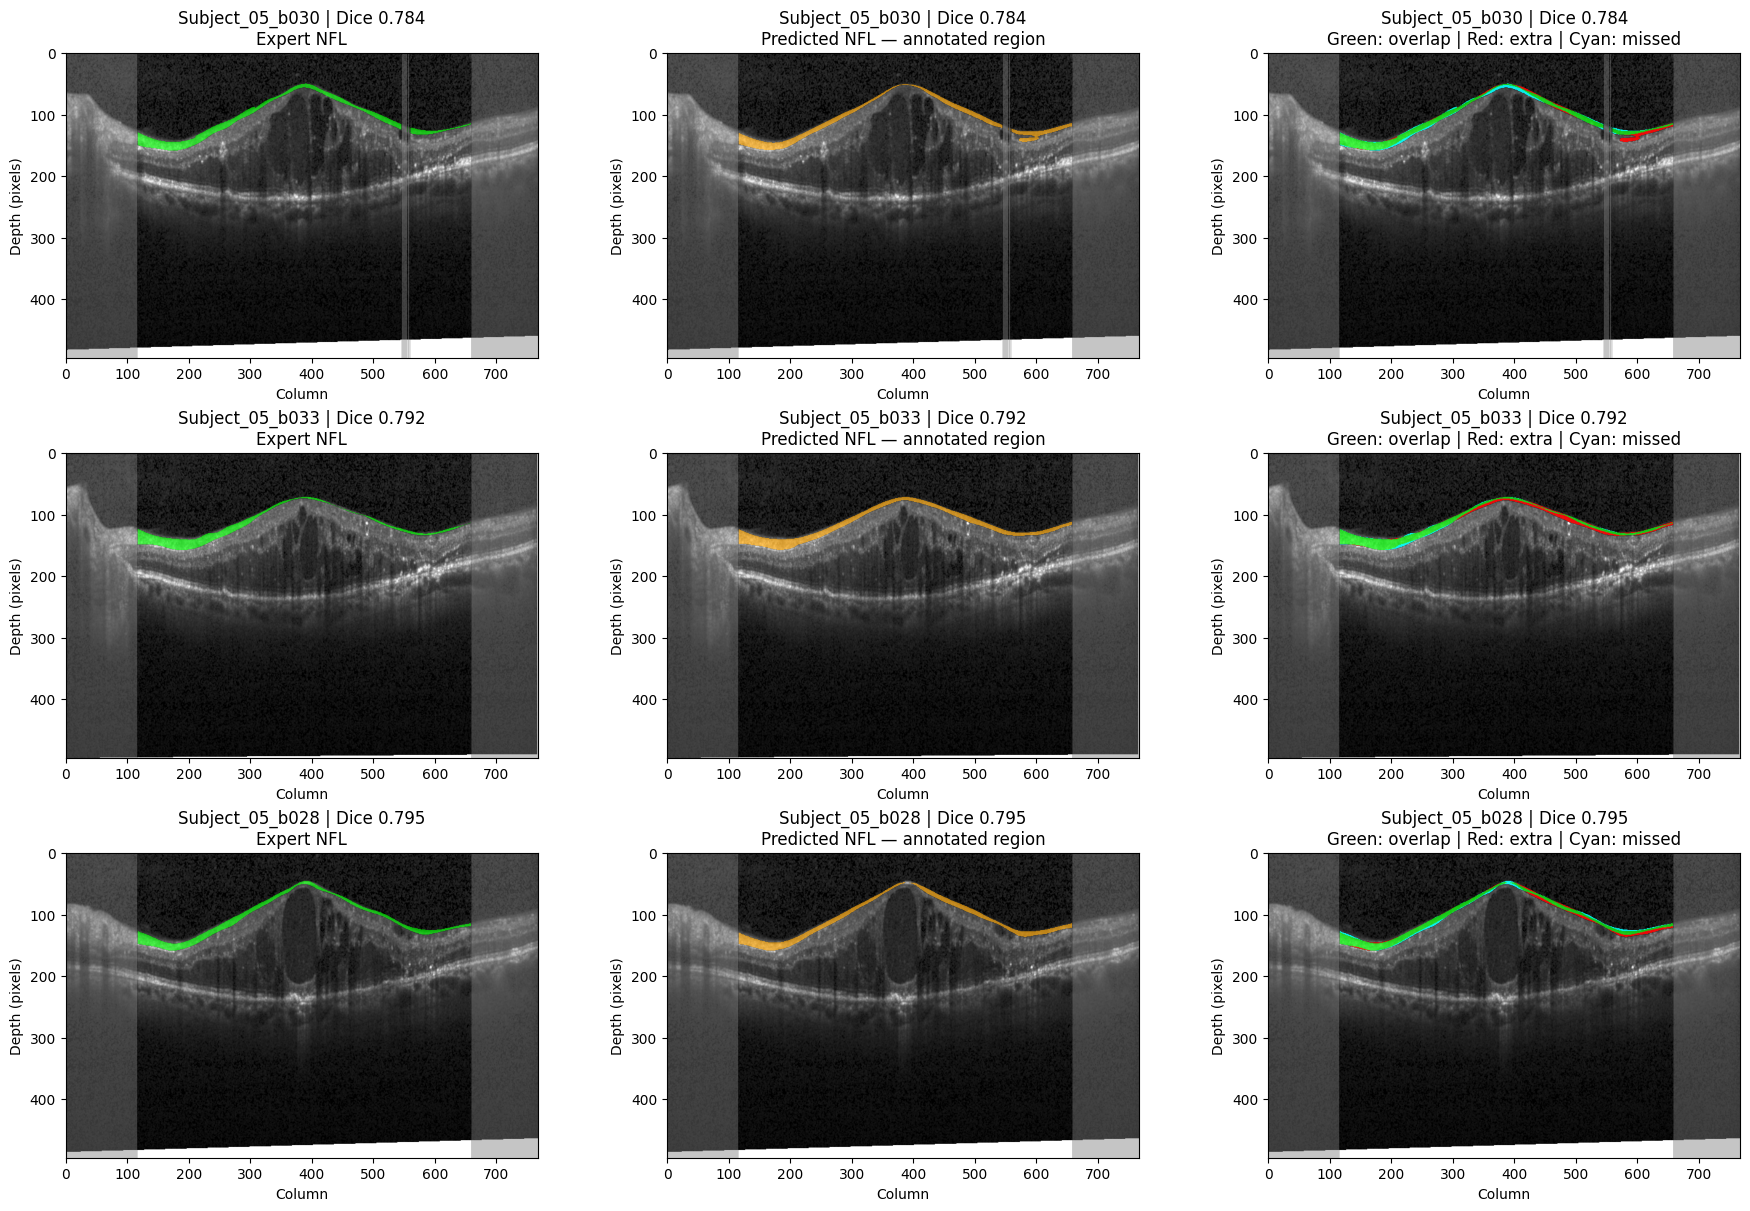

Saved: /home/btech10862.24/OCT-RTFL/outputs/validation_review/lowest_dice_cases.png


In [2]:
selected = scores.head(3)

fig, axes = plt.subplots(
    len(selected),
    3,
    figsize=(18, 4 * len(selected)),
    squeeze=False,
    constrained_layout=True,
)

for row_index, record in enumerate(selected.itertuples(index=False)):
    case_id = record.case_id

    image = np.asarray(
        Image.open(RAW / "imagesTr" / f"{case_id}_0000.png")
    )
    target = np.asarray(
        Image.open(RAW / "labelsTr" / f"{case_id}.png")
    )
    prediction = np.asarray(
        Image.open(VALIDATION / f"{case_id}.png")
    )

    valid = target != 2
    true_nfl = (target == 1) & valid
    predicted_nfl = (prediction == 1) & valid

    # Transparent overlays preserve the underlying OCT image.
    true_overlay = np.zeros((*target.shape, 4), dtype=np.float32)
    true_overlay[true_nfl] = [0.0, 1.0, 0.0, 0.65]

    predicted_overlay = np.zeros_like(true_overlay)
    predicted_overlay[predicted_nfl] = [1.0, 0.65, 0.0, 0.65]

    error_overlay = np.zeros_like(true_overlay)
    error_overlay[true_nfl & predicted_nfl] = [0.0, 1.0, 0.0, 0.7]
    error_overlay[predicted_nfl & ~true_nfl] = [1.0, 0.0, 0.0, 0.9]
    error_overlay[true_nfl & ~predicted_nfl] = [0.0, 1.0, 1.0, 0.9]

    # Shade regions that have no ground-truth annotation.
    ignored_overlay = np.zeros_like(true_overlay)
    ignored_overlay[~valid] = [0.5, 0.5, 0.5, 0.45]

    panels = [
        ("Expert NFL", true_overlay),
        ("Predicted NFL — annotated region", predicted_overlay),
        ("Green: overlap | Red: extra | Cyan: missed", error_overlay),
    ]

    for column_index, (title, overlay) in enumerate(panels):
        ax = axes[row_index, column_index]
        ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        ax.imshow(overlay)
        ax.imshow(ignored_overlay)
        ax.set_title(f"{case_id} | Dice {record.dice:.3f}\n{title}")
        ax.set_xlabel("Column")
        ax.set_ylabel("Depth (pixels)")

figure_path = REPORTS / "lowest_dice_cases.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

In [ ]:
from scipy.io import loadmat


def extract_nfl_boundaries(prediction):
    """Extract one contiguous NFL interval per column, without smoothing."""
    nfl = prediction == 1
    height, width = nfl.shape

    # Padding makes transitions at the image edges detectable.
    padded = np.pad(
        nfl.astype(np.int8),
        ((1, 1), (0, 0)),
        constant_values=0,
    )
    transitions = np.diff(padded, axis=0)

    starts = transitions == 1
    ends = transitions == -1
    segment_count = starts.sum(axis=0)

    top = np.full(width, np.nan, dtype=float)
    bottom = np.full(width, np.nan, dtype=float)

    single = segment_count == 1
    top[single] = starts[:, single].argmax(axis=0)
    bottom[single] = ends[:, single].argmax(axis=0)

    status = np.full(width, "multiple_segments", dtype=object)
    status[segment_count == 0] = "missing"
    status[single] = "single_segment"

    # Bottom is exclusive: a one-pixel segment has thickness 1.
    return top, bottom, status


DUKE = ROOT / "duke_dataset" / "2015_BOE_Chiu"
boundary_records = []
manual_cache = {}

for record in scores.itertuples(index=False):
    case_id = record.case_id
    subject_id, slice_text = case_id.rsplit("_b", 1)
    slice_index = int(slice_text)

    if subject_id not in manual_cache:
        manual_cache[subject_id] = loadmat(
            DUKE / f"{subject_id}.mat",
            variable_names=["manualLayers1"],
        )["manualLayers1"]

    layers = manual_cache[subject_id][:, :, slice_index]

    prediction = np.asarray(
        Image.open(VALIDATION / f"{case_id}.png")
    )
    height, width = prediction.shape

    gt_top = layers[0].astype(float) - 1
    gt_bottom = layers[1].astype(float) - 1

    valid_gt = (
        np.isfinite(gt_top)
        & np.isfinite(gt_bottom)
        & (gt_top >= 0)
        & (gt_bottom < height)
        & (gt_bottom >= gt_top)
    )

    pred_top, pred_bottom, status = extract_nfl_boundaries(prediction)

    gt_thickness = np.where(valid_gt, gt_bottom - gt_top, np.nan)
    pred_thickness = pred_bottom - pred_top

    evaluated = valid_gt & (status == "single_segment")
    valid_count = int(valid_gt.sum())

    def conditional_mean(values):
        return float(values[evaluated].mean()) if evaluated.any() else np.nan

    boundary_records.append({
        "case_id": case_id,
        "valid_gt_columns": valid_count,
        "evaluated_columns": int(evaluated.sum()),
        "coverage_pct": 100 * evaluated.sum() / valid_count
                        if valid_count else np.nan,
        "missing_columns": int(
            (valid_gt & (status == "missing")).sum()
        ),
        "multiple_segment_columns": int(
            (valid_gt & (status == "multiple_segments")).sum()
        ),
        "gt_zero_thickness_columns": int(
            (valid_gt & (gt_thickness == 0)).sum()
        ),
        "ilm_mae_px": conditional_mean(np.abs(pred_top - gt_top)),
        "nfl_gcl_mae_px": conditional_mean(
            np.abs(pred_bottom - gt_bottom)
        ),
        "thickness_mae_px": conditional_mean(
            np.abs(pred_thickness - gt_thickness)
        ),
        "thickness_bias_px": conditional_mean(
            pred_thickness - gt_thickness
        ),
    })

    pd.DataFrame({
        "column": np.arange(width),
        "gt_valid": valid_gt,
        "prediction_status": status,
        "gt_ilm_y": np.where(valid_gt, gt_top, np.nan),
        "gt_nfl_gcl_y": np.where(valid_gt, gt_bottom, np.nan),
        "pred_ilm_y": pred_top,
        "pred_nfl_gcl_y": pred_bottom,
        "gt_thickness_px": gt_thickness,
        "pred_thickness_px": pred_thickness,
        "evaluated": evaluated,
    }).to_csv(REPORTS / f"{case_id}_boundaries.csv", index=False)

boundary_scores = pd.DataFrame(boundary_records)
boundary_scores.to_csv(
    REPORTS / "boundary_metrics.csv",
    index=False,
)

print("Mean of per-scan errors, on evaluable columns:")
display(
    boundary_scores[
        ["ilm_mae_px", "nfl_gcl_mae_px",
         "thickness_mae_px", "thickness_bias_px"]
    ].mean().to_frame("mean")
)

coverage = (
    100 * boundary_scores["evaluated_columns"].sum()
    / boundary_scores["valid_gt_columns"].sum()
)
print(f"Overall evaluable-column coverage: {coverage:.2f}%")

display(
    boundary_scores.sort_values(
        "thickness_mae_px", ascending=False
    ).head(5)
)

Mean of per-scan errors, on evaluable columns:


,mean
ilm_mae_px,0.983515
nfl_gcl_mae_px,1.513825
thickness_mae_px,1.649567
thickness_bias_px,0.101895


Overall evaluable-column coverage: 99.72%


,case_id,valid_gt_columns,evaluated_columns,coverage_pct,missing_columns,multiple_segment_columns,gt_zero_thickness_columns,ilm_mae_px,nfl_gcl_mae_px,thickness_mae_px,thickness_bias_px
1,Subject_05_b033,542,542,100.000000,0,0,0,0.817343,2.758303,3.166052,2.125461
0,Subject_05_b030,530,502,94.716981,0,28,0,1.141434,2.354582,2.595618,-0.894422
9,Subject_05_b018,542,542,100.000000,0,0,2,1.101476,1.948339,2.201107,-0.278598
5,Subject_05_b026,542,542,100.000000,0,0,0,1.079336,1.562731,2.114391,0.867159
2,Subject_05_b028,542,537,99.077491,5,0,0,1.184358,2.227188,2.026071,0.324022


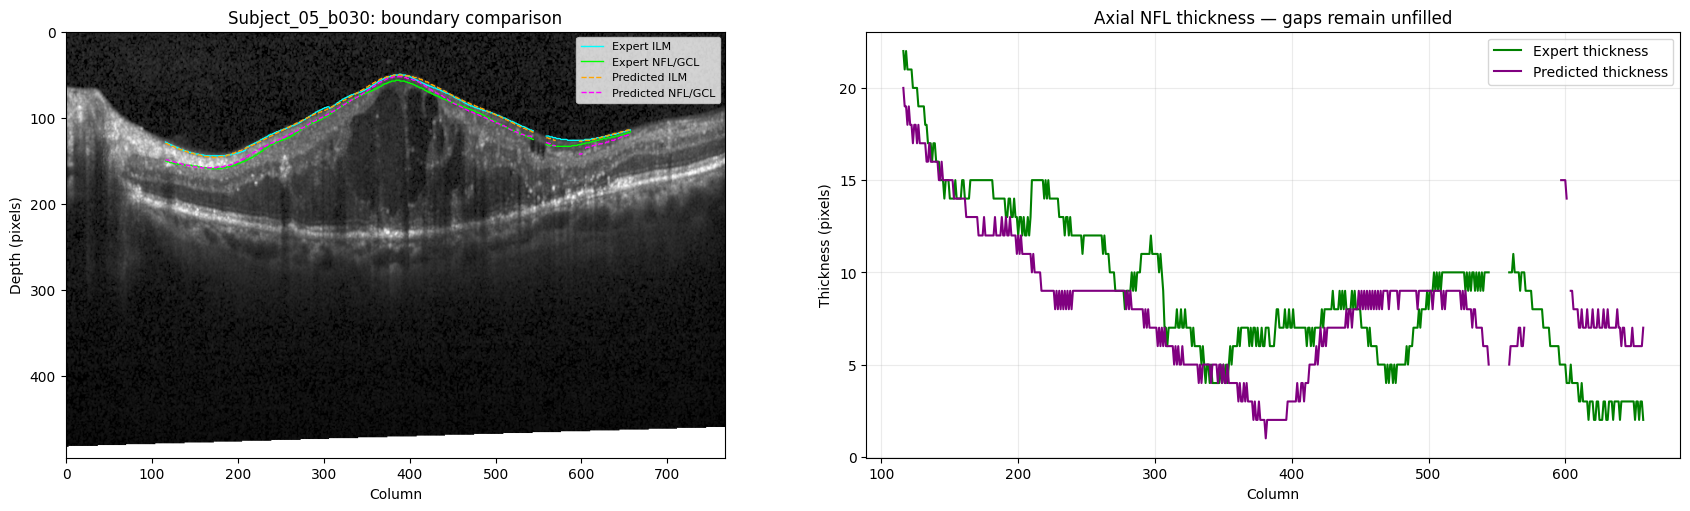

In [4]:
case_id = scores.iloc[0]["case_id"]

curves = pd.read_csv(
    REPORTS / f"{case_id}_boundaries.csv"
)
image = np.asarray(
    Image.open(RAW / "imagesTr" / f"{case_id}_0000.png")
)

x = curves["column"].to_numpy()
valid_gt = curves["gt_valid"].to_numpy(dtype=bool)

fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 5),
    constrained_layout=True,
)

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)

for column, label, color, style in [
    ("gt_ilm_y", "Expert ILM", "cyan", "-"),
    ("gt_nfl_gcl_y", "Expert NFL/GCL", "lime", "-"),
    ("pred_ilm_y", "Predicted ILM", "orange", "--"),
    ("pred_nfl_gcl_y", "Predicted NFL/GCL", "magenta", "--"),
]:
    y = curves[column].to_numpy(dtype=float)
    axes[0].plot(
        x, np.where(valid_gt, y, np.nan),
        color=color, linestyle=style,
        linewidth=1, label=label,
    )

axes[0].set_title(f"{case_id}: boundary comparison")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Depth (pixels)")
axes[0].legend(fontsize=8)

axes[1].plot(
    x, curves["gt_thickness_px"],
    color="green", label="Expert thickness",
)
axes[1].plot(
    x,
    np.where(valid_gt, curves["pred_thickness_px"], np.nan),
    color="purple", label="Predicted thickness",
)

axes[1].set_title("Axial NFL thickness — gaps remain unfilled")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Thickness (pixels)")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.savefig(
    REPORTS / f"{case_id}_boundary_thickness.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()